In [18]:
import json
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

RESULTS_DIR = Path("/home/nakano/cuda_test")


def load_llc_results(name):
    with open(RESULTS_DIR / "llc_results" / f"{name}.json") as f:
        return json.load(f)


def compute_lambdahat(rec, n, burn_in_ratio=0.9):
    trace = np.array(rec["loss_trace"])
    init_loss = rec["init_loss"]
    itemp = 1 / np.log(n)
    burn_in = int(len(trace) * burn_in_ratio)
    valid = trace[burn_in:]
    valid = valid[~np.isnan(valid) & ~np.isinf(valid)]
    if len(valid) == 0:
        return np.nan
    return (np.mean(valid) - init_loss) * n * itemp


# ─── CIFAR10 (train) のLLCのみを読み込む ───
llc_data = load_llc_results("cifar10_train_llc_full")
n = llc_data["n_llc_samples_actual"]
steps = np.array([r["step"] for r in llc_data["results"]])
lambdahats = np.array([compute_lambdahat(r, n, burn_in_ratio=0.9) for r in llc_data["results"]])

print(f"{len(steps)} checkpoints loaded")

46 checkpoints loaded


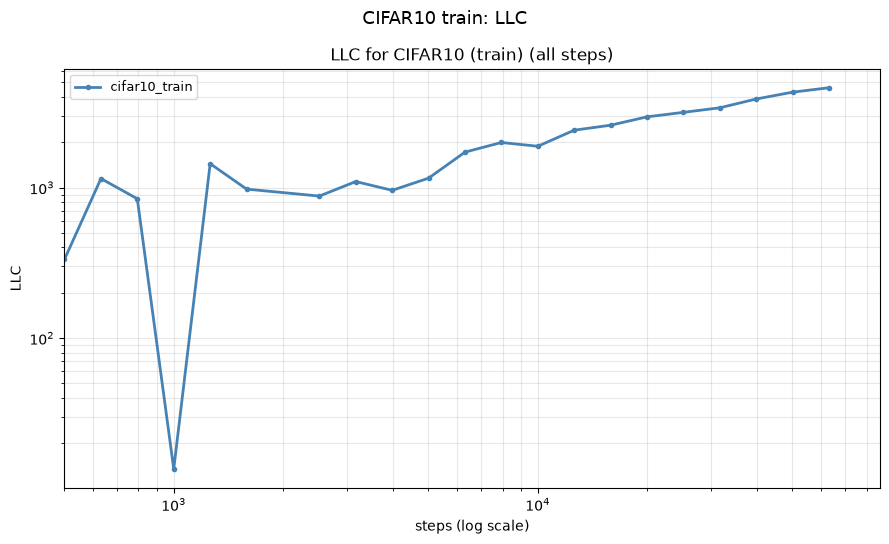

In [19]:
STEP_LIMIT = None  # 序盤に絞りたい場合はステップ数を指定。Noneなら全範囲

fig, ax = plt.subplots(figsize=(9, 5.5))

mask = ~np.isnan(lambdahats) & (steps >= 1) & (lambdahats > 0)
if STEP_LIMIT is not None:
    mask &= (steps <= STEP_LIMIT)

ax.plot(steps[mask], lambdahats[mask], marker="o", markersize=3,
        color="steelblue", linewidth=2, label="cifar10_train")

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlim(left=5e2)
ax.set_xlabel("steps (log scale)")
ax.set_ylabel(r"LLC")
title_suffix = f" (steps <= {STEP_LIMIT})" if STEP_LIMIT is not None else " (all steps)"
ax.set_title(f"LLC for CIFAR10 (train){title_suffix}")
ax.legend(fontsize=9)
ax.grid(alpha=0.3, which="both")

fig.suptitle("CIFAR10 train: LLC", fontsize=13)
fig.tight_layout()

suffix = f"_upto{STEP_LIMIT}" if STEP_LIMIT is not None else "_full"
plt.savefig(RESULTS_DIR / f"llc_train_only{suffix}.pdf", bbox_inches="tight")
plt.show()

n_points = 21
scaling exponent (slope) = 0.5771
intercept = 0.9574  (LLC ~ steps^0.5771 * 10^0.9574)


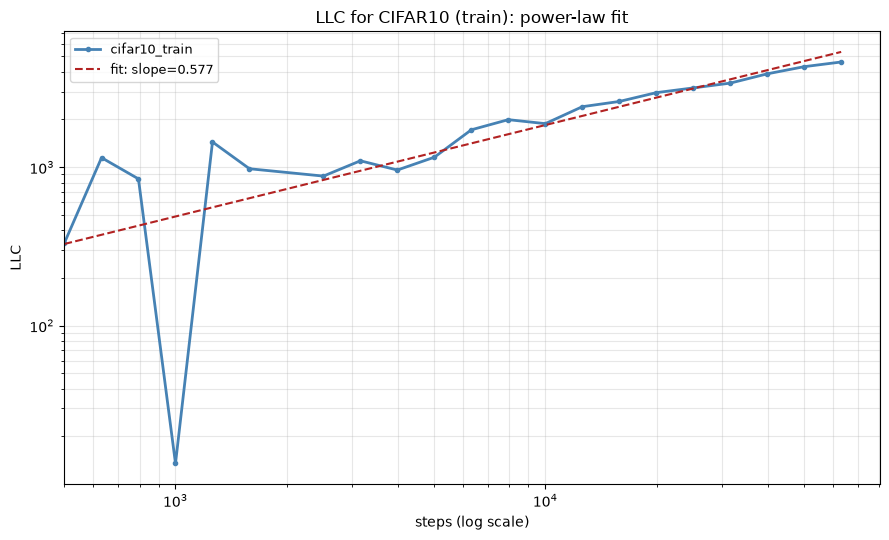

In [20]:
# ─── log-logでの傾き（べき乗則のスケーリング指数）を計算 ───
fit_mask = ~np.isnan(lambdahats) & (steps >= 5e2) & (lambdahats > 0)
log_steps = np.log10(steps[fit_mask])
log_lambdahats = np.log10(lambdahats[fit_mask])

slope, intercept = np.polyfit(log_steps, log_lambdahats, 1)
print(f"n_points = {fit_mask.sum()}")
print(f"scaling exponent (slope) = {slope:.4f}")
print(f"intercept = {intercept:.4f}  (LLC ~ steps^{slope:.4f} * 10^{intercept:.4f})")

fig, ax = plt.subplots(figsize=(9, 5.5))
ax.plot(steps[fit_mask], lambdahats[fit_mask], marker="o", markersize=3,
        color="steelblue", linewidth=2, label="cifar10_train")

fit_x = np.array([steps[fit_mask].min(), steps[fit_mask].max()])
fit_y = 10 ** (slope * np.log10(fit_x) + intercept)
ax.plot(fit_x, fit_y, linestyle="--", color="firebrick",
        label=f"fit: slope={slope:.3f}")

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlim(left=5e2)
ax.set_xlabel("steps (log scale)")
ax.set_ylabel(r"LLC")
ax.set_title("LLC for CIFAR10 (train): power-law fit")
ax.legend(fontsize=9)
ax.grid(alpha=0.3, which="both")
fig.tight_layout()
plt.show()

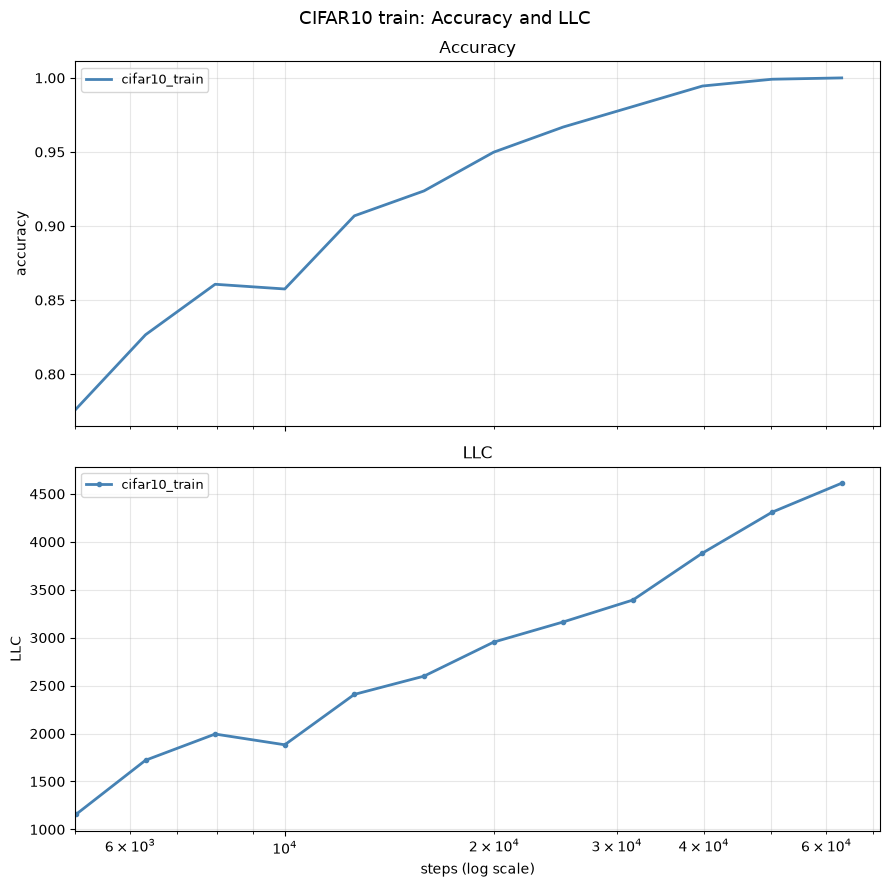

In [ ]:
# ─── Accuracy + LLC (cifar10_train のみ, 下限5000) ───
with open(RESULTS_DIR / "dsb_eval_results.json") as f:
    cifar_eval = json.load(f)

cifar_steps = np.array([r["step"] for r in cifar_eval])
cifar_train_acc = np.array([r["train_acc"] for r in cifar_eval])

STEP_LOWER =-5000

fig, axes = plt.subplots(2, 1, figsize=(9, 9), sharex=True)

# ── 上段: Accuracy ──
ax = axes[0]
acc_mask = cifar_steps >= STEP_LOWER
ax.plot(cifar_steps[acc_mask], cifar_train_acc[acc_mask], color="steelblue",
        linewidth=2, label="cifar10_train")
ax.set_xscale("log")
ax.set_ylabel("accuracy")
ax.set_title("Accuracy")
ax.legend(fontsize=9)
ax.grid(alpha=0.3, which="both")

# ── 下段: LLC ──
ax = axes[1]
llc_mask = ~np.isnan(lambdahats) & (steps >= STEP_LOWER)
ax.plot(steps[llc_mask], lambdahats[llc_mask], marker="o", markersize=3,
        color="steelblue", linewidth=2, label="cifar10_train")
ax.set_xscale("log")
ax.set_xlabel("steps (log scale)")
ax.set_ylabel(r"LLC")
ax.set_title("LLC")
ax.legend(fontsize=9)
ax.grid(alpha=0.3, which="both")

ax.set_xlim(left=STEP_LOWER)

fig.suptitle("CIFAR10 train: Accuracy and LLC", fontsize=13)
fig.tight_layout()

plt.savefig(RESULTS_DIR / f"llc_train_only_acc_llc_from{STEP_LOWER}.pdf", bbox_inches="tight")
plt.show()